In [1]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

#### SOURCE MECHANISM

Original params:  [333   8 118]


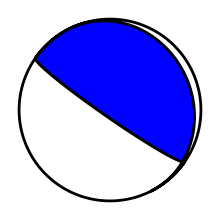

In [2]:
np.random.seed(2025)

# get true params for synthetic test
benchmark = (np.array([333, 8, 118]), np.array([125, 83, 86]))
true_params = benchmark[0]
print('Original params: ', true_params)

# plot corresponding beachball
beachball = fn.beachball(true_params)

# velocity model, assume depth, vp and vs cols
velocity_model = TauPyModel(model='ak135')
data_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(data_path)

In [3]:
eq_lat = 2.0964
eq_lon = 97.1131
hdepth = 30.0  # km

In [4]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 30.0 km, P velocity = 6.5 km/s, S velocity = 3.85 km/s


In [5]:
unc = (3.1275938939507688e-06, 5.329208956669851e-05, 5.591222696695143e-05)
unc = np.array(unc)
unc

array([0.    , 0.0001, 0.0001])

#### STATION LOCAION 1

In [ ]:
# set up hyperparameters for inversion
epdist_1 = 39.72  # degrees - epicentral distance
azimuth_1 = 153.06  # degrees - azimuth of seismometer

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
velocities = fn.extract_velocities(lookup_table, hdepth)

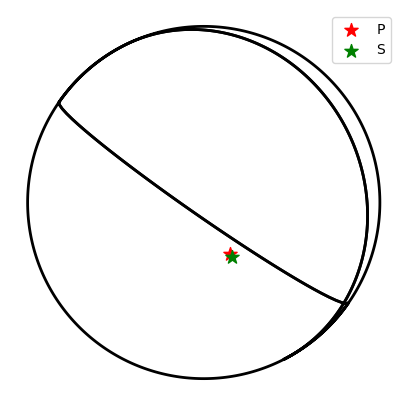

In [21]:
fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = fn.beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
az = azimuth_1
r1 = 100 * takeoff_angles[0]/90
r2 = 100 * takeoff_angles[1]/90
x1 = r1 * np.sin(np.deg2rad(az))
y1 = r1 * np.cos(np.deg2rad(az))
x2 = r2 * np.sin(np.deg2rad(az))
y2 = r2 * np.cos(np.deg2rad(az))

ax.scatter(x1, y1, color='red', s=100, marker='*', label='P')
ax.scatter(x2, y2, color='green', s=100, marker='*', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [ ]:
# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoff_angles, velocities)

model_Ao1 = radiation_model_1(np.deg2rad(true_params), set_Ao=True, return_A=True)
radiation_model_1.set_Uo(unc) # TODO

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)

radiation_model_1.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_1, config, start)

print(f'Convergence rate: {radiation_model_1.get_convergence_rate():.0f}%')


In [21]:
fn.unit_vec(model_Ao1)

array([-0.0534,  0.3893, -0.9196])

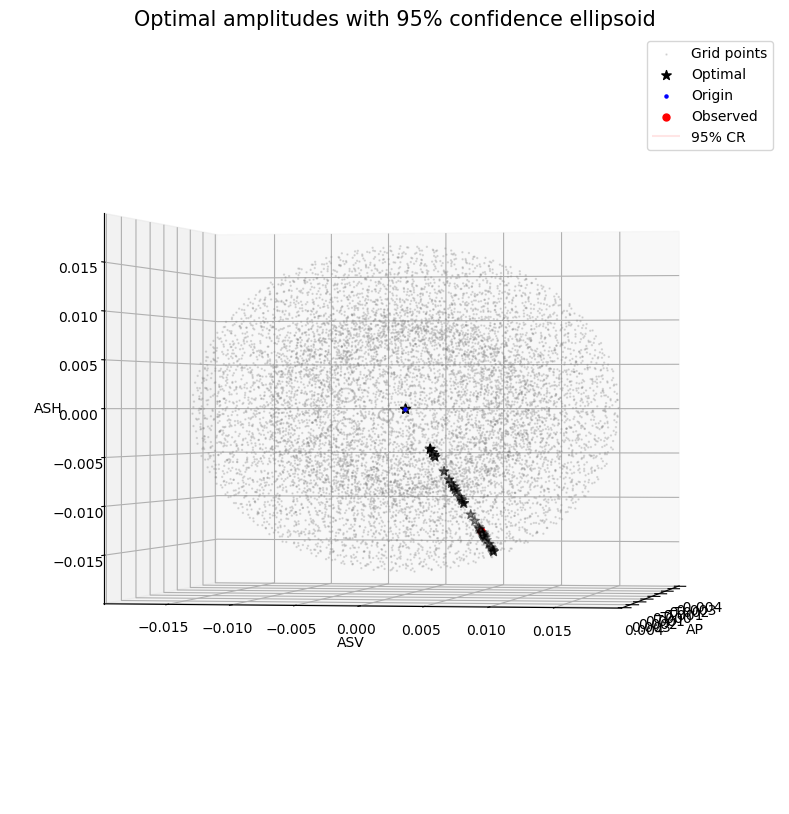

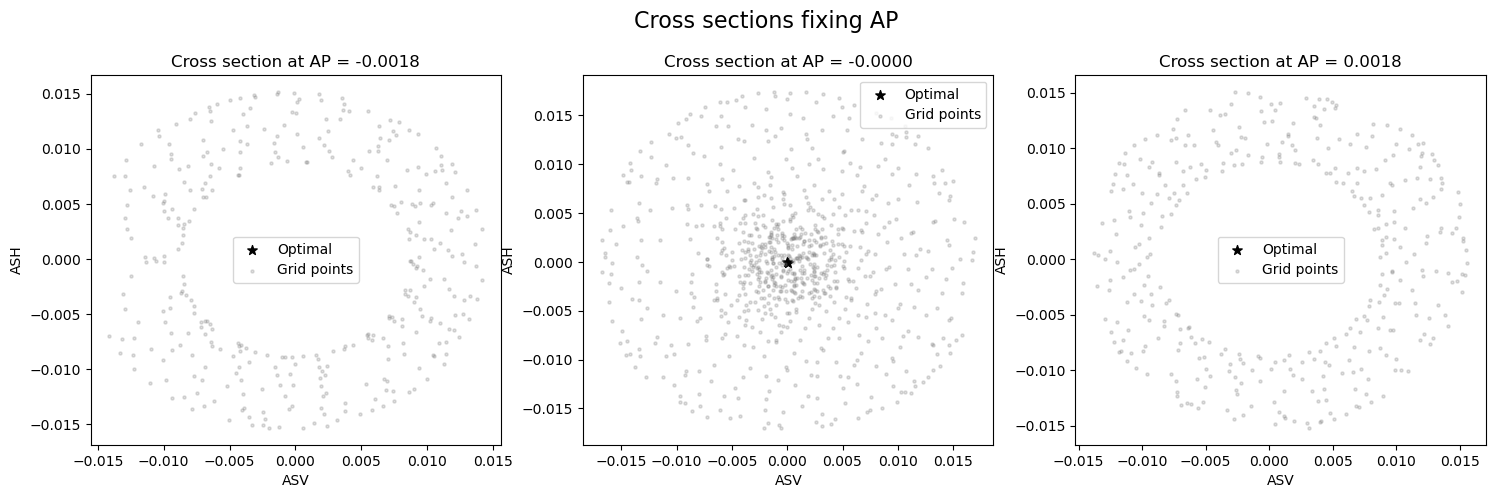

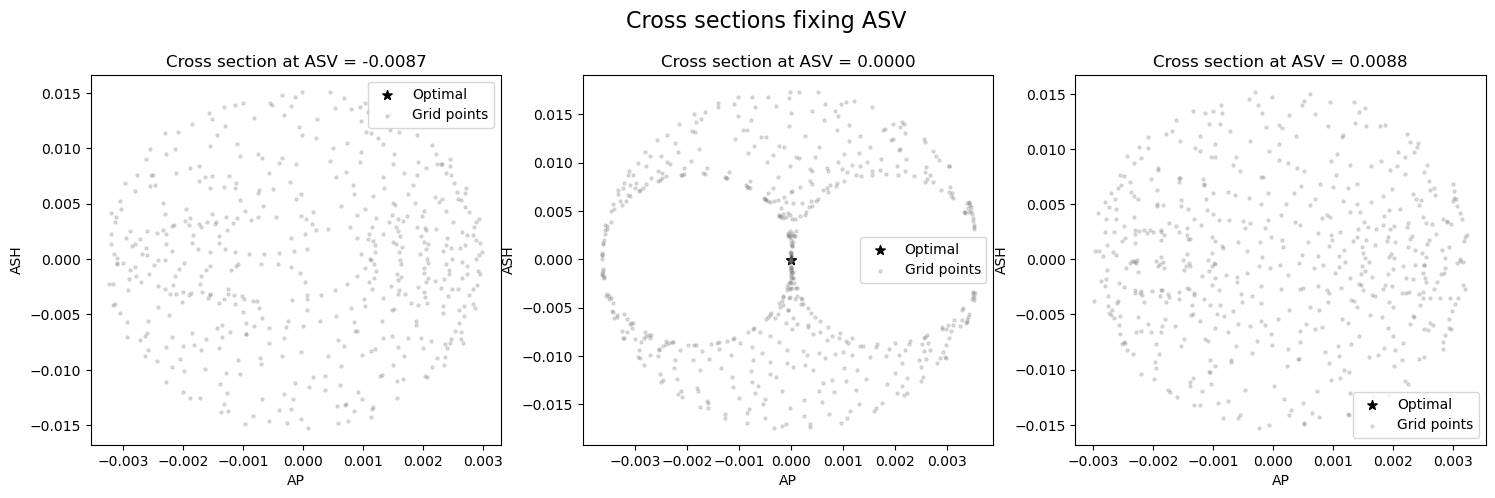

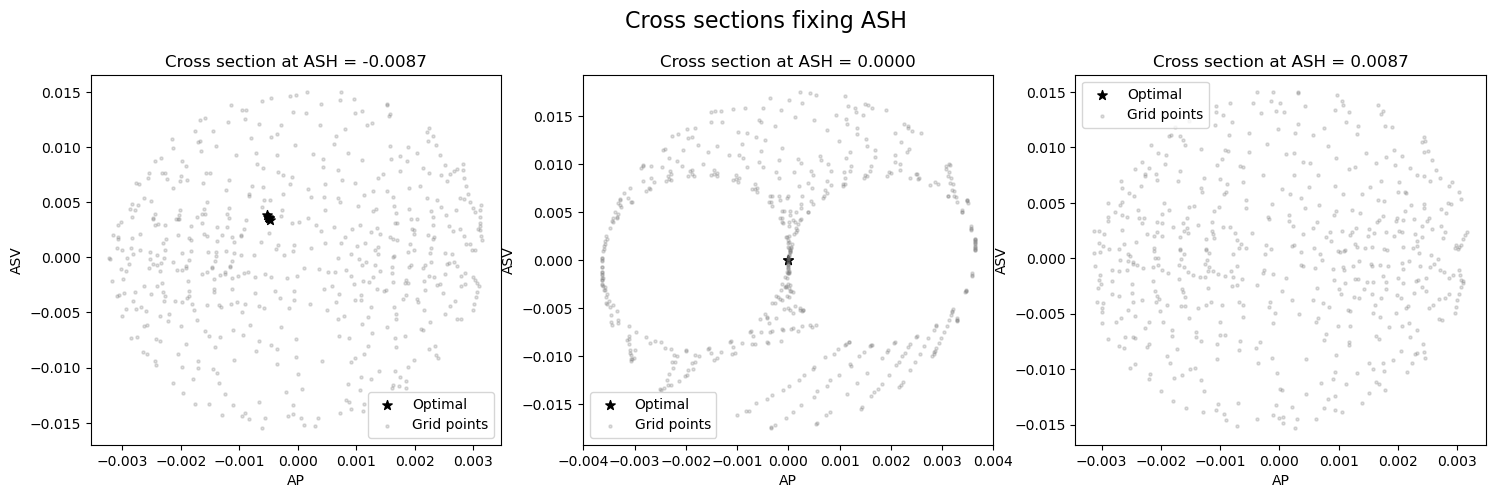

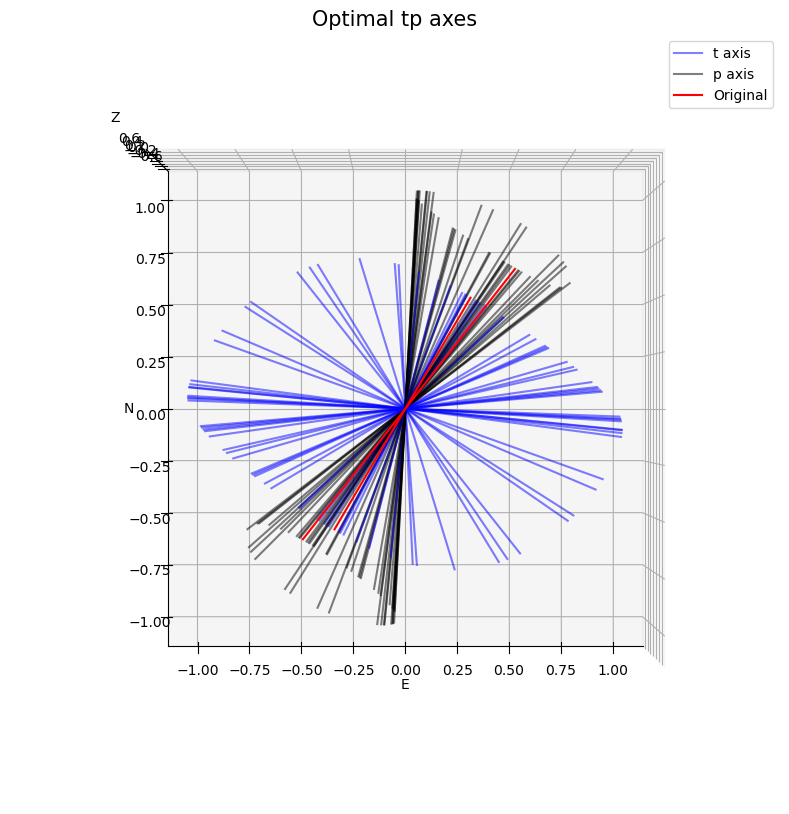

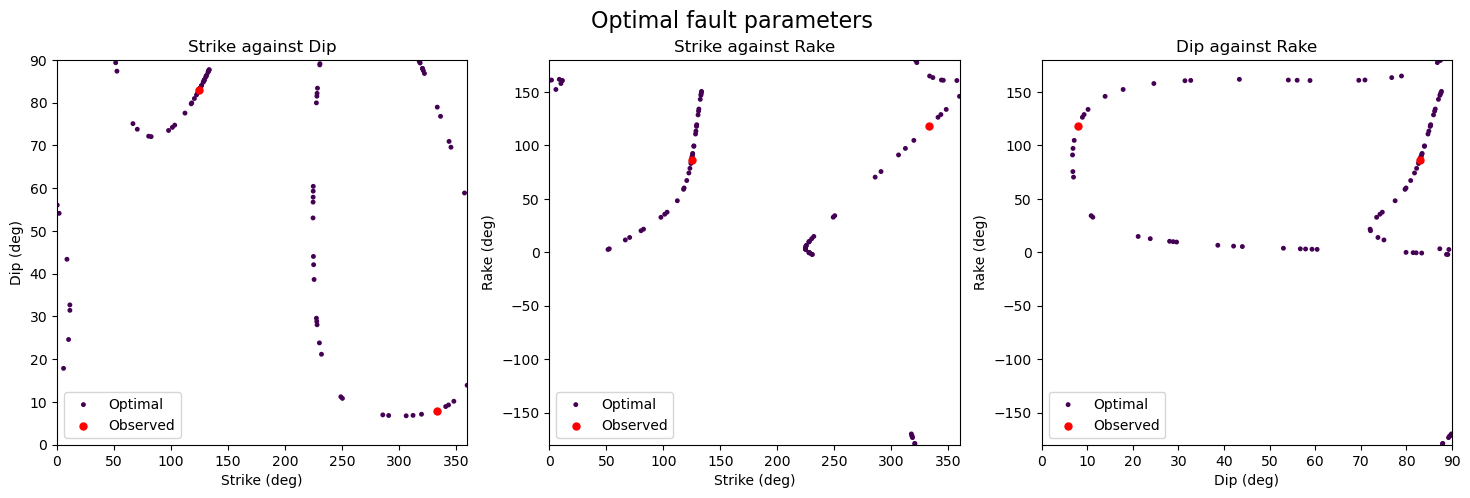

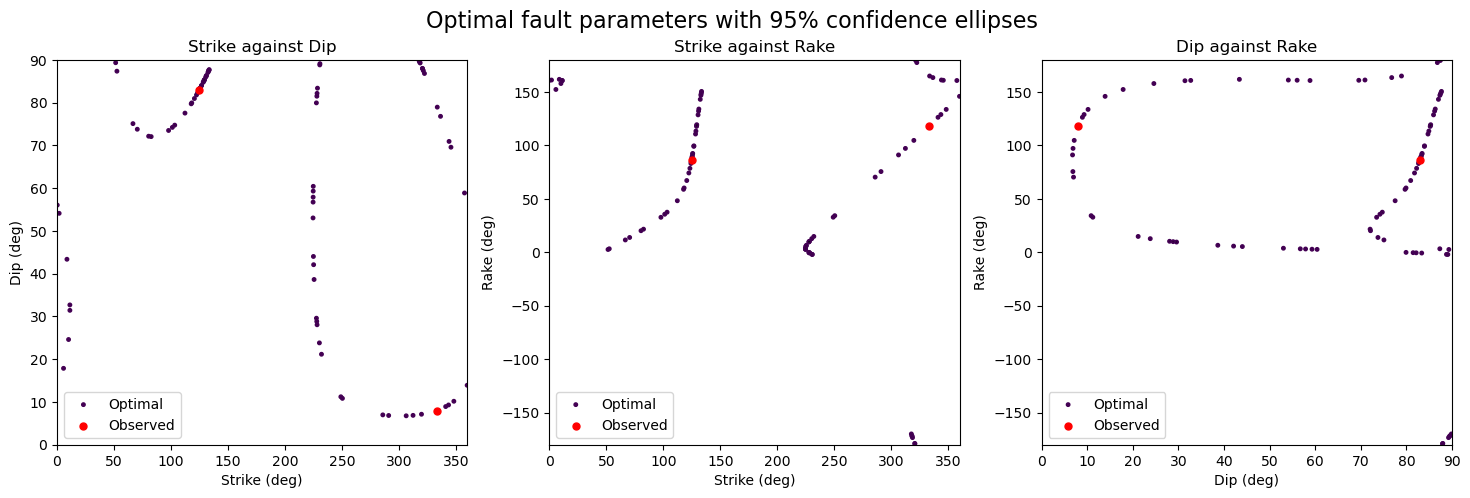

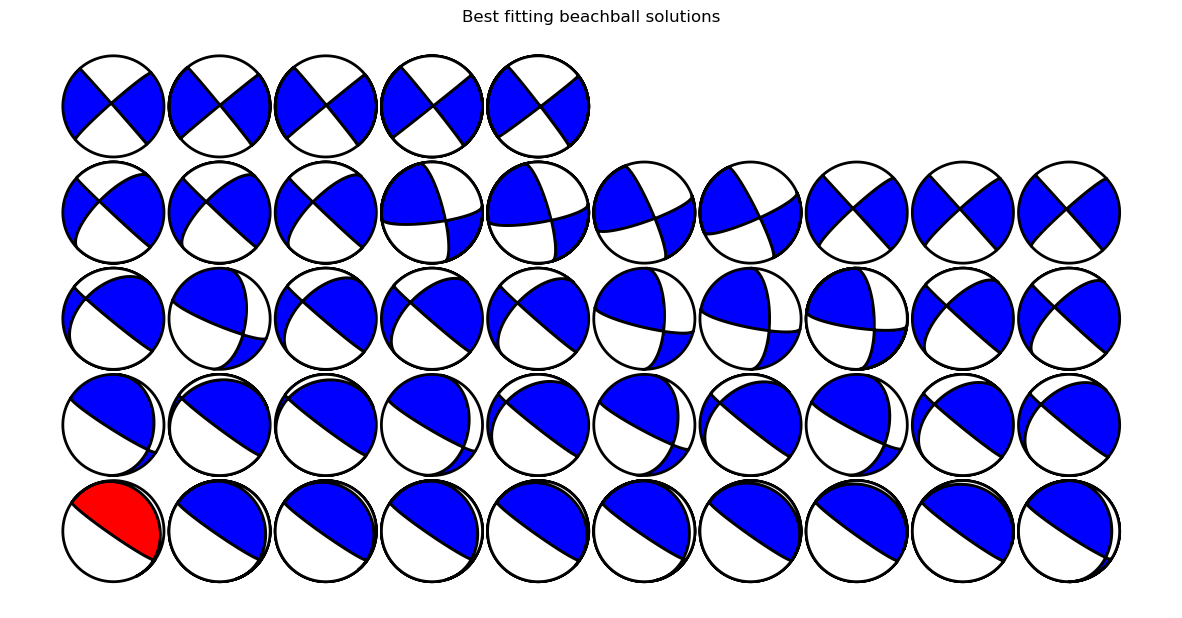

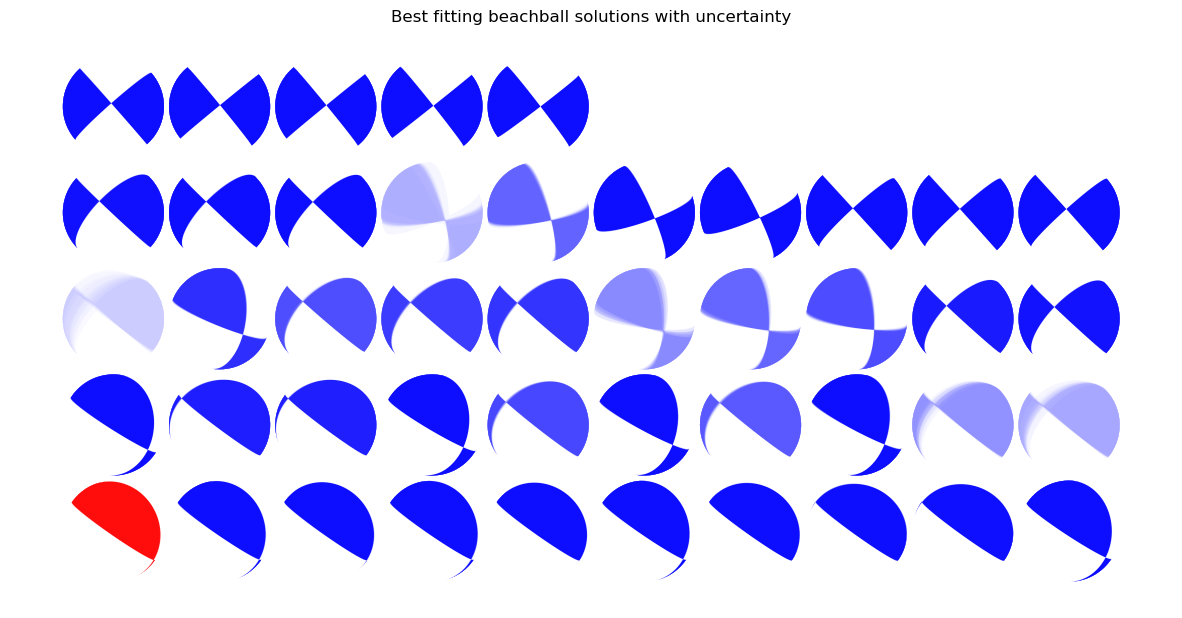

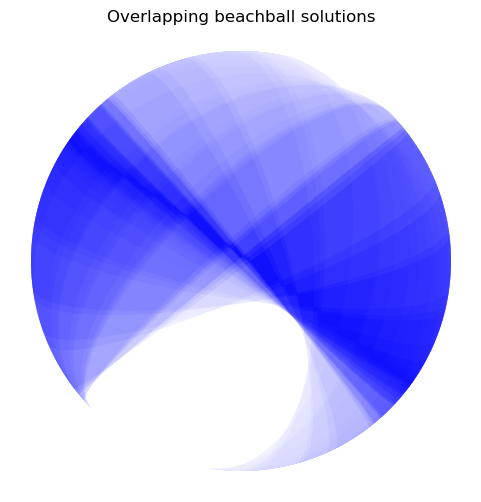

In [22]:
# amplitude plot
radiation_model_1.reset_grid_amplitudes()
radiation_model_1.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_1, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=True, cross_section=[3,3,3],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_1, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis')
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis',
                    uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

#### STATION LOCAION 2

In [10]:
# set up hyperparameters for inversion
epdist_2 = 63.59  # degrees - epicentral distance
azimuth_2 = 140.94  # degrees - azimuth of seismometer

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_2, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_2, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
velocities = fn.extract_velocities(lookup_table, hdepth)


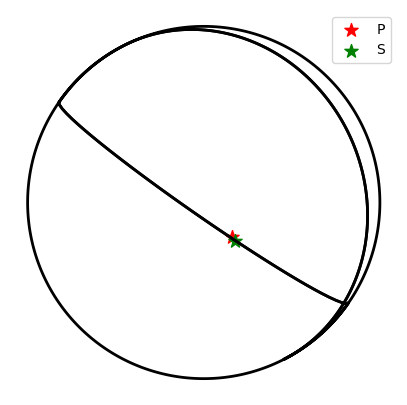

In [19]:
fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = fn.beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
az = azimuth_2
r1 = 100 * takeoff_angles[0]/90
r2 = 100 * takeoff_angles[1]/90
x1 = r1 * np.sin(np.deg2rad(az))
y1 = r1 * np.cos(np.deg2rad(az))
x2 = r2 * np.sin(np.deg2rad(az))
y2 = r2 * np.cos(np.deg2rad(az))

ax.scatter(x1, y1, color='red', s=100, marker='*', label='P')
ax.scatter(x2, y2, color='green', s=100, marker='*', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [ ]:

# initialize model
radiation_model_2 = rm.RadiationModel(np.deg2rad(azimuth_2), takeoff_angles, velocities)

model_Ao2 = radiation_model_2(np.deg2rad(true_params), set_Ao=True, return_A=True)

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)

radiation_model_2.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_2, config, start)

print(f'Convergence rate: {radiation_model_2.get_convergence_rate():.0f}%')


In [22]:
fn.unit_vec(model_Ao2)

array([ 0.0026,  0.2978, -0.9546])

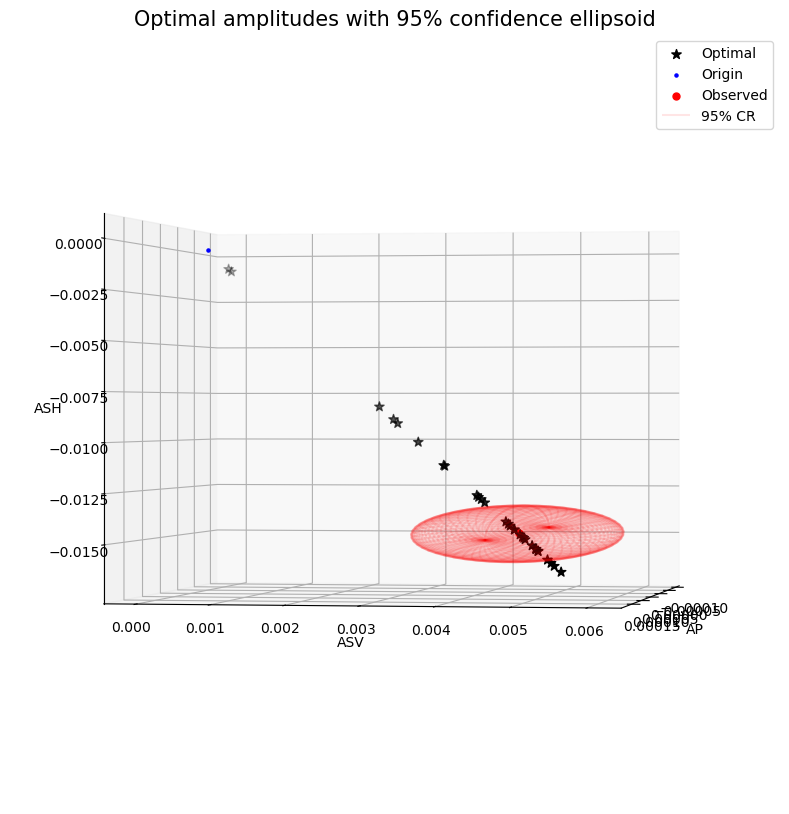

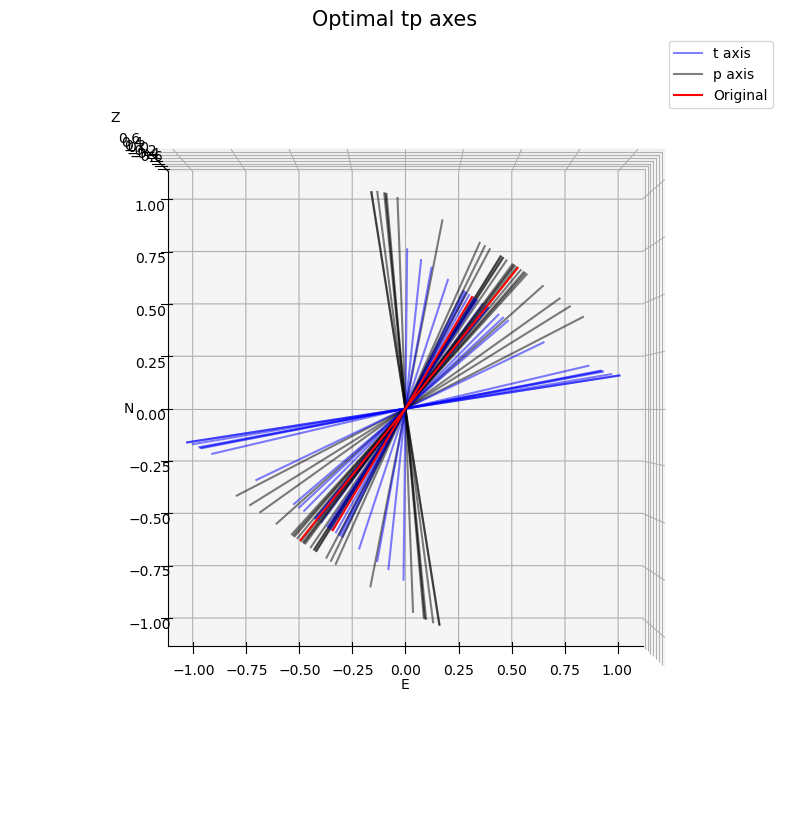

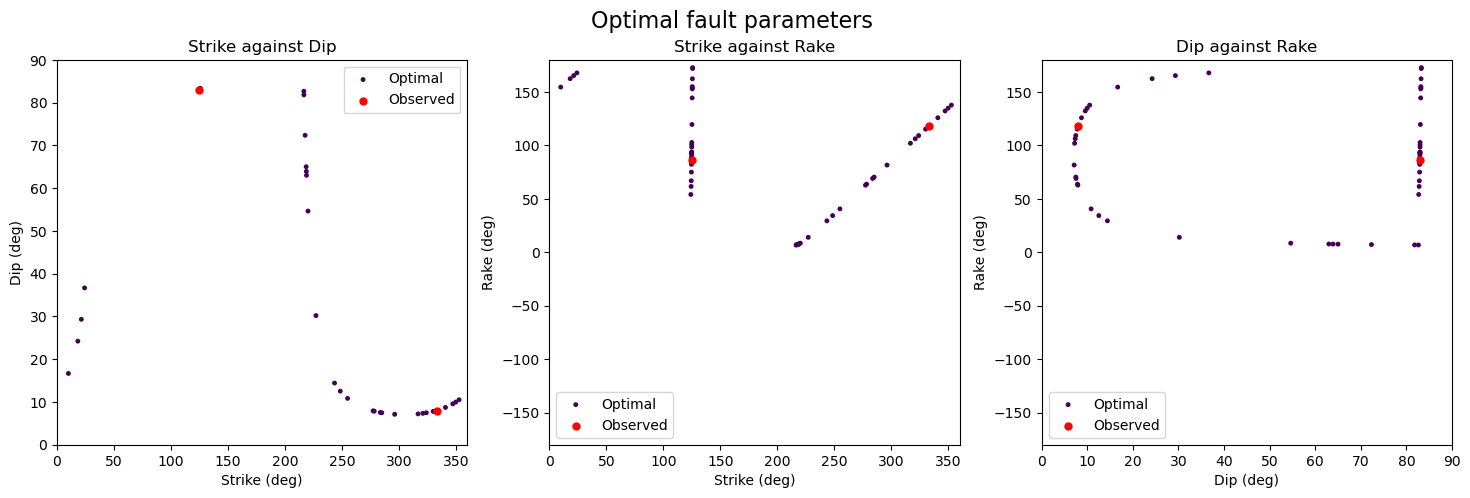

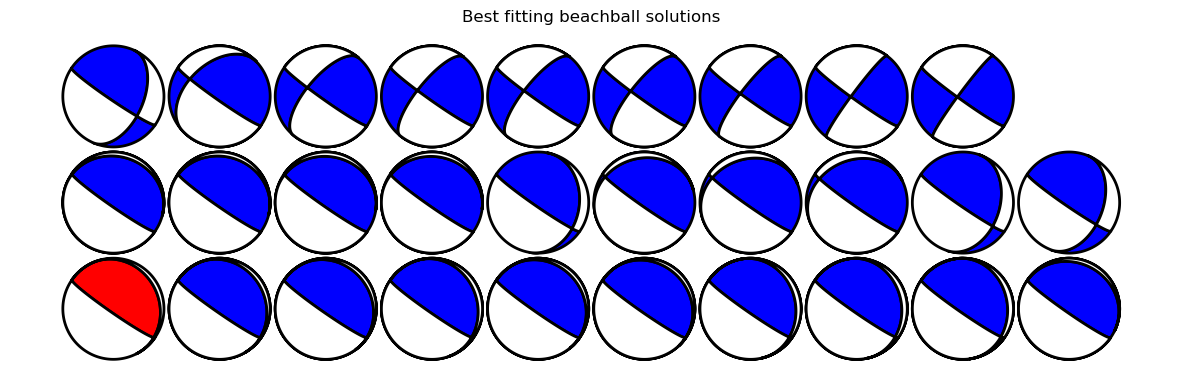

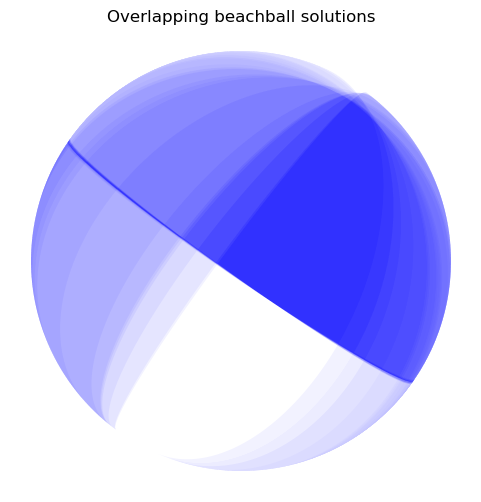

In [13]:
# amplitude plot
radiation_model_2.reset_grid_amplitudes()
radiation_model_2.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_2, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_2, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_2, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(radiation_model_2, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(radiation_model_2, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
# plots.beachballs(radiation_model_2, order_by='kagan', width=10,  max_plot=50,
#                  original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(radiation_model_2, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)